# 1. 手書き数字文字画像の形態情報計算モジュール実装及び動作確認

## 1.1 明るさと太さ計算モジュールの実装

In [1]:
def get_intensity(img):
    threshold = 0.5

    img_min, img_max = img.min(), img.max()
    mask = (img >= img_min + (img_max - img_min) * threshold)
    avg_intensity = np.median(img[mask])

    return avg_intensity

In [2]:
import numpy as np
from skimage import transform
from scipy import ndimage

# Skeletonize と distance transform を使って太さを計算
from skimage.morphology import skeletonize
from skimage.util import img_as_bool

def get_thickness(img, threshold: float = 0.5, scale: int = 1) -> float:
    """
    Compute the mean stroke thickness of a digit image.

    Parameters
    ----------
    img : np.ndarray
        Input image of shape (H, W) or (1, H, W).
    threshold : float
        Relative threshold for binarization (0〜1)。
    scale : int
        アップスケール倍率（サブピクセル解析用、デフォルト=1）。

    Returns
    -------
    thickness : float
        平均ストローク幅。
    """
    # 形状調整
    if img.ndim == 3 and img.shape[0] == 1:
        img = img[0]
    img = np.asarray(img, dtype=np.float32)

    # アップスケール
    if scale > 1:
        img = transform.rescale(img, scale, order=3, anti_aliasing=True)

    # 二値化
    img_min, img_max = img.min(), img.max()
    bin_thresh = img_min + (img_max - img_min) * threshold
    binary = img >= bin_thresh

    # 骨格抽出
    skeleton = skeletonize(img_as_bool(binary))

    # 距離マップ (背景からの距離)
    dist_map = ndimage.distance_transform_edt(binary)

    # 骨格上の点の距離値を集め、平均をとって2倍 = 太さ
    if np.any(skeleton):
        thickness = 2.0 * np.mean(dist_map[skeleton]) / scale
    else:
        thickness = 0.0

    return thickness


## 1.2 形態情報計算モジュールの動作確認

In [45]:
import os

os.chdir("/home/hashikami/projects/Diff")

In [50]:
import torch

# 5の画像を使う場合

images_obs = torch.load("./resources/image9_size32_scale255.pt")
x_obs = torch.load("./resources/metrics_image9.pt")

In [51]:
images_obs.shape

torch.Size([1, 32, 32])

In [52]:
x_obs

tensor([[81.2734,  2.3036]], device='cuda:0')

In [53]:
intensity = get_intensity(images_obs)
thickness = get_thickness(images_obs)
intensity, thickness


(162.76562, 3.273226930725703)

In [60]:
# metricsのサンプルを取得

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from dataset.morphomnist import MorphoMNISTLike
from diffusion.utils.utils import resize_images


batch_size = 1
dataset = MorphoMNISTLike(root_dir="/home/hashikami/datadrive/MorphoMNIST",
                            columns=['intensity', 'thickness'], train=False)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
intensity = next(iter(data_loader))['intensity'][:, None].float()
thickness = next(iter(data_loader))['thickness'][:, None].float()
metrics = torch.cat([intensity, thickness], dim=1)
images = next(iter(data_loader))['image'].unsqueeze(1) * 1.0
resized_images = resize_images(images, (32, 32)).squeeze(1)

In [61]:
metrics

tensor([[176.0828,   2.5624]])

In [62]:
intensity = get_intensity(images.squeeze(1).squeeze(0))
thickness = get_thickness(images.squeeze(1).squeeze(0))
print(intensity, thickness)

resized_intensity = get_intensity(resized_images)
resized_thickness = get_thickness(resized_images)
print(resized_intensity, resized_thickness)

114.0 2.3472718241315027
98.98242 2.4756210742282874


# 2. 反事実的画像編集結果の評価：目標値と実測値との比較

In [63]:
from pathlib import Path
from pipeline.utils import dict2namespace
import yaml


config_path = Path("config/config_all.yaml")
with open(config_path, "r") as f:
    config_raw = yaml.load(f, Loader=yaml.FullLoader)
config = dict2namespace(config_raw)

In [64]:
%load_ext autoreload
%autoreload 2

from pipeline.causal_pipeline import CausalPipeline

pipeline = CausalPipeline(config)

In [65]:
# Morpho-MNISTデータのロード

from dataset.morphomnist import load_morphomnist_like

dataset_dir = "/home/hashikami/datadrive/MorphoMNIST"
_, _, metrics_df = load_morphomnist_like(dataset_dir)
metrics = metrics_df.to_numpy()
metrics = metrics[:, [1, 0]] # thickness, intensityの順序が逆のため入れ替える

In [66]:
# notearsの適用

from pipeline.causal_pipeline import CausalPipeline


pipeline = CausalPipeline(config)
B_est = pipeline.run_causal_discovery(metrics)
B_est

Running causal discovery for meta-data


array([[0, 0],
       [1, 0]], dtype=int32)

In [67]:
# careflの訓練

config.carefl.scale_shift_base = True
config.carefl_training.epochs = 30
carefl = pipeline.train_meta_causal_model(metrics, B_est)

Training meta-causal model


100%|██████████| 30/30 [02:16<00:00,  4.54s/it]


In [68]:
# causal_pipeline.pyを修正してリロードした場合
# careflを再学習するのは手間のためpipeline.careflを編集前に学習したもので初期化

pipeline.carefl = carefl

In [69]:
## UNetのロード
import torch
from diffusion.diffusion_model.models.model11 import UNet
from diffusion.utils.utils import load_checkpoint, load_json
import torch.optim  as optim


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoise_model = UNet().to(device)
optimizer = optim.Adam(denoise_model.parameters(), lr=1e-3)


# 実験設定ファイルパス
file_path = "/home/hashikami/results/2025-07-17_16/config_20250717.json"
config = load_json(file_path)
epochs = config['epochs']
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[int(epochs * ratio) for ratio in [0.5, 0.8]],
    gamma=0.2
)


# checkpointの読み込み
checkpoint_path = "/home/hashikami/checkpoint/checkpoint_2025-07-17_18.pth"
denoise_model, optimizer, scheduler, start_epoch, loss = load_checkpoint(denoise_model, optimizer, scheduler, filename=checkpoint_path)


In [72]:
pipeline.denoise_model = denoise_model

In [70]:
# 5の画像を使う場合

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
images_obs = torch.load("./resources/image5_size32_scale255.pt", map_location=device).unsqueeze(0) / 255.0
x_obs = torch.load("./resources/metrics_image5.pt", map_location=device)

In [71]:
print(x_obs)

tensor([[166.7316,   1.8436]], device='cuda:0')


In [73]:
# 反事実推論のための介入値の設定
w = 0.8
cf_dict = {
    'intensity': [80.0, 100.0, 150.0, 200.0, 250.0],
    'thickness': [1.5, 2.0, 2.5, 3.0, 3.5]
}

# 反事実推論のための画像の保存
cf_intensity_images = []
cf_thickness_images = []
for meta, cf_vals in cf_dict.items():
    if meta == 'intensity':
        cf_idx = [0]
    elif meta == 'thickness':
        cf_idx = [1]
    else:
        raise ValueError(f"Invalid meta: {meta}")
    
    for cf_val in cf_vals:
        imgs = pipeline.counterfactual_editing(images_obs, x_obs, cf_idx, cf_val, w=w)
        if meta == 'intensity':
            cf_intensity_images.append(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy())
        elif meta == 'thickness':
            cf_thickness_images.append(imgs[-1][0].permute(1, 2, 0).detach().cpu().numpy())
        else:
            raise ValueError(f"Invalid meta: {meta}")
        

sampling loop time step: 100%|██████████| 500/500 [00:09<00:00, 50.59it/s]


In [74]:
cf_intensity_images[0].shape

(32, 32, 1)

In [78]:
# 反事実的に編集された画像のメタ情報の実測値を保存

measured_cf_intensity = []
for cf_intensity_image in cf_intensity_images:
    measured_cf_intensity.append(get_intensity(cf_intensity_image.reshape(1, 32, 32) * 255.0))

measured_cf_thickness = []
for cf_thickness_image in cf_thickness_images:
    measured_cf_thickness.append(get_thickness(cf_thickness_image.reshape(1, 32, 32) * 255.0))
    

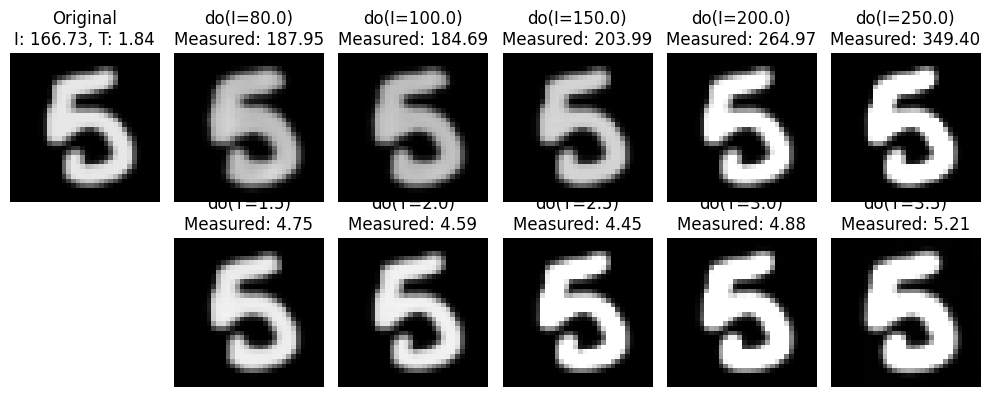

In [82]:
# 元の画像と反事実的編集結果画像の可視化

fig, axes = plt.subplots(2, 6, figsize=(10, 4))

axes[0, 0].imshow((images_obs[0].permute(1, 2, 0) * 255.0).detach().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title(f"Original\nI: {x_obs[0, 0]:.2f}, T: {x_obs[0, 1]:.2f}")

for meta, cf_vals in cf_dict.items():
    if meta == 'intensity':
        for i, cf_val in enumerate(cf_vals):
            axes[0, i+1].imshow(cf_intensity_images[i] * 255.0, cmap='gray', vmin=0, vmax=255)
            axes[0, i+1].set_title(f"do(I={cf_val})\nMeasured: {measured_cf_intensity[i]:.2f}")
    if meta == 'thickness':
        for i, cf_val in enumerate(cf_vals):
            axes[1, i+1].imshow(cf_thickness_images[i] * 255.0, cmap='gray', vmin=0, vmax=255)
            axes[1, i+1].set_title(f"do(T={cf_val})\nMeasured: {measured_cf_thickness[i]:.2f}")

# 全ての軸の表示を消す
for row in axes:
    for ax in row:
        ax.axis('off')

plt.tight_layout()
plt.show()